In [1]:
import sys
import os

# 1. Rileva se l'esecuzione avviene su Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("⚡ Esecuzione su Google Colab.")
    from google.colab import drive
    drive.mount('/content/drive')
    
    # URL del tuo repository GitHub e percorso in Colab
    REPO_URL = "https://github.com/giacomosalvatori03/3D_Perception.git"
    REPO_DIR = "/content/3D_Perception"
    
    # Se la repo non è ancora presente su Colab la clona, altrimenti scarica gli aggiornamenti
    if not os.path.exists(REPO_DIR):
        print("📥 Clonazione del repository da GitHub...")
        !git clone {REPO_URL} {REPO_DIR}
    else:
        print("🔄 Aggiornamento del codice da GitHub...")
        %cd {REPO_DIR}
        !git pull
        
    os.chdir(REPO_DIR)
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
        
    # PERCORSO DEL DATASET SU GOOGLE DRIVE
    # Modifica questo percorso con la posizione esatta della cartella 'kitti_validation' sul tuo Drive
    DATASET_PATH = "/content/drive/MyDrive/3D_Perception/data/kitti_validation"

else:
    print("💻 Esecuzione in Locale.")
    PROJECT_ROOT = os.path.abspath('..')
    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    DATASET_PATH = os.path.join(PROJECT_ROOT, 'data/kitti_validation')

print(f"✅ Directory corrente: {os.getcwd()}")
print(f"✅ Dataset Path: {DATASET_PATH}")

Mounted at /content/drive
📥 Clonazione del repository da GitHub...
Cloning into '/content/3D_Perception'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 11 (delta 0), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 568.29 KiB | 31.57 MiB/s, done.
✅ Directory corrente: /content/3D_Perception
✅ Dataset Path: /content/drive/MyDrive/3D_Perception/data/kitti_subset


Totale frame caricati nel subset: 1000
Frame ID: 000050
Dimensioni Immagine: (375, 1242, 3)
Numero Punti LiDAR: 108348
Numero Oggetti GT: 5

🚘 [Oggetto 1] Classe: Car
   • BBox 2D [xmin, ymin, xmax, ymax]: [683.34 170.98 803.44 257.43]
   • Dimensioni 3D [h, w, l] (m):     [1.49 1.56 4.34]
   • Posizione 3D [x, y, z] (m):      [ 2.51  1.49 14.75]
   • Rotazione Y (rad):               -1.59
   • Troncamento / Occlusione:        0.0 / 0

🚘 [Oggetto 2] Classe: Car
   • BBox 2D [xmin, ymin, xmax, ymax]: [262.97 182.23 469.76 318.  ]
   • Dimensioni 3D [h, w, l] (m):     [1.42 1.53 4.12]
   • Posizione 3D [x, y, z] (m):      [-3.06  1.56  9.79]
   • Rotazione Y (rad):               -1.61
   • Troncamento / Occlusione:        0.0 / 0

🚘 [Oggetto 3] Classe: Car
   • BBox 2D [xmin, ymin, xmax, ymax]: [ 910.25  159.81 1241.    374.  ]
   • Dimensioni 3D [h, w, l] (m):     [1.59 1.59 3.89]
   • Posizione 3D [x, y, z] (m):      [2.61 1.55 2.39]
   • Rotazione Y (rad):               -1.60
   • Tro

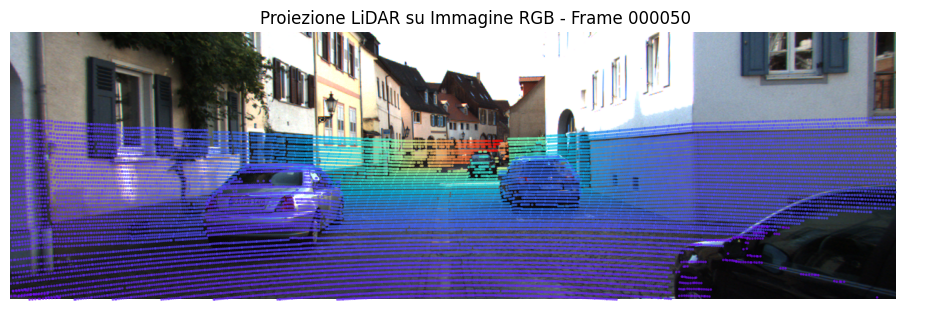

In [4]:
import sys
import matplotlib.pyplot as plt

# Aggiungi la root del progetto al path di Python per importare src
sys.path.append('..')

from src.kitti_dataset import KittiDataset

# Inizializza il dataset
dataset = KittiDataset(data_root=DATASET_PATH)
print(f"Totale frame caricati nel subset: {len(dataset)}")

# Carica il primo sample
sample = dataset[50]
image = sample['image']
points = sample['points']
calib = sample['calib']
objects = sample['objects']

print(f"Frame ID: {sample['id']}")
print(f"Dimensioni Immagine: {image.shape}")
print(f"Numero Punti LiDAR: {points.shape[0]}")
print(f"Numero Oggetti GT: {len(objects)}")

# Stampa dettagliata di ciascun oggetto GT
for i, obj in enumerate(objects, 1):
    print(f"\n🚘 [Oggetto {i}] Classe: {obj['type']}")
    print(f"   • BBox 2D [xmin, ymin, xmax, ymax]: {obj['bbox_2d'].round(2)}")
    print(f"   • Dimensioni 3D [h, w, l] (m):     {obj['dimensions_3d'].round(2)}")
    print(f"   • Posizione 3D [x, y, z] (m):      {obj['location_3d'].round(2)}")
    print(f"   • Rotazione Y (rad):               {obj['rotation_y']:.2f}")
    print(f"   • Troncamento / Occlusione:        {obj['truncation']} / {obj['occlusion']}")

# Test proiezione LiDAR su Immagine RGB
pts_2d, depth, valid_mask = calib.velo2img(points)

# Disegna la proiezione con mappa di colori basata sulla profondità (distance z)
plt.figure(figsize=(12, 5))
plt.imshow(image)

# Filtra solo i punti che cadono all'interno dell'immagine
img_h, img_w, _ = image.shape
in_bounds = (pts_2d[:, 0] >= 0) & (pts_2d[:, 0] < img_w) & \
            (pts_2d[:, 1] >= 0) & (pts_2d[:, 1] < img_h)

plt.scatter(pts_2d[in_bounds, 0], pts_2d[in_bounds, 1], c=depth[in_bounds], cmap='rainbow', s=1, alpha=0.5)
plt.title(f"Proiezione LiDAR su Immagine RGB - Frame {sample['id']}")
plt.axis('off')
plt.show()